# Proyecto No.1
## Detección de Ciberacoso en Redes Sociales
 
**Integrantes:**
* Cindy Gualim, 21226
* Javier Linares, 231135
* Luis Pedro Lira, 23669

In [2]:
!pip install nltk tqdm


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:

import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier # ¡Añadido para el Ensamble!
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Configuraciones visuales y de entorno
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
tqdm.pandas() 

# Descargar recursos NLP
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("Librerías importadas y entorno configurado correctamente.")

Librerías importadas y entorno configurado correctamente.


### 1. Carga de Datos y Limpieza Inicial

In [5]:
# Carga de datos
df = pd.read_csv("cyberbullying_tweets.csv")
original_len = len(df)

# Limpieza básica
df = df.dropna()
df = df.drop_duplicates(subset="tweet_text")

print(f"Total original: {original_len} tweets.")
print(f"Total tras remover nulos y duplicados: {len(df)} tweets.")

Total original: 47692 tweets.
Total tras remover nulos y duplicados: 46017 tweets.


### 2. Análisis Exploratorio de Datos (EDA)

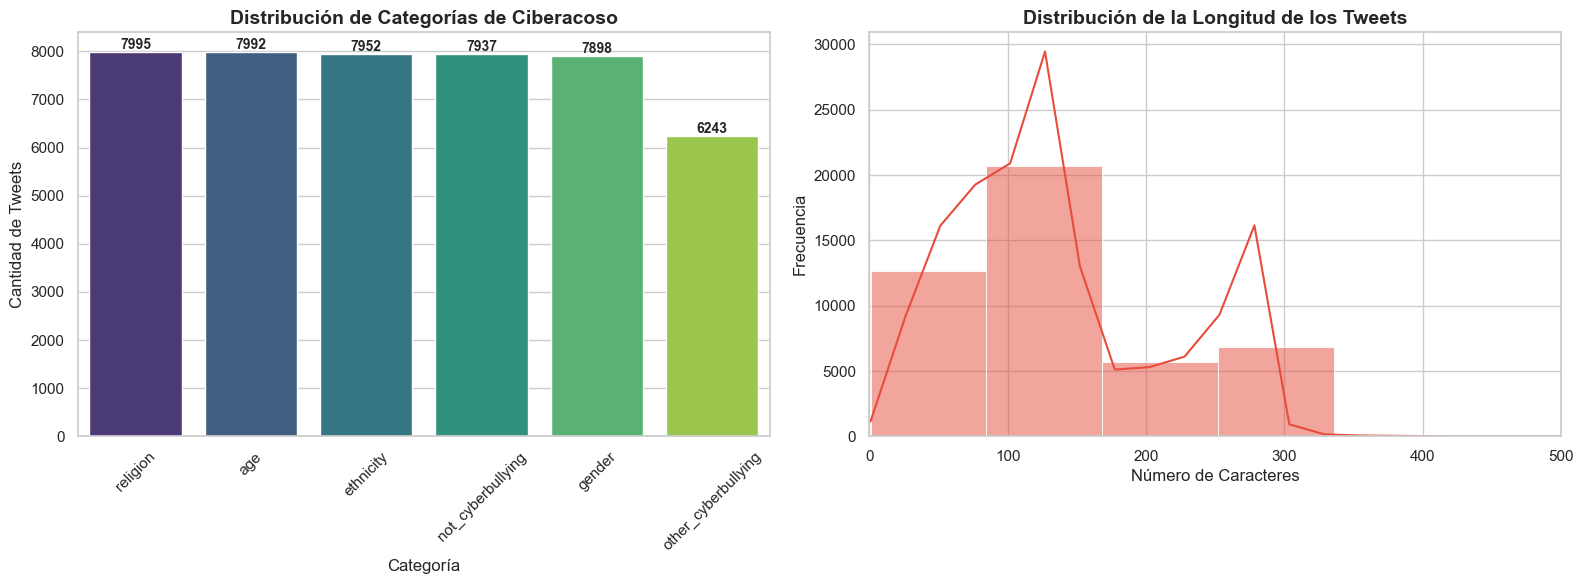

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Distribución de clases con conteos
orden_clases = df['cyberbullying_type'].value_counts().index
ax1 = sns.countplot(data=df, x="cyberbullying_type", order=orden_clases, palette="viridis", ax=axes[0])
axes[0].set_title("Distribución de Categorías de Ciberacoso", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Cantidad de Tweets")
axes[0].tick_params(axis='x', rotation=45)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gráfica 2: Distribución de longitudes
df["length"] = df["tweet_text"].apply(len)
sns.histplot(df["length"], bins=60, kde=True, color="#e74c3c", ax=axes[1])
axes[1].set_title("Distribución de la Longitud de los Tweets", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Número de Caracteres")
axes[1].set_ylabel("Frecuencia")
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

### 3. Pre-procesamiento de Texto (NLP Pipeline)

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def procesar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+", "", texto)      # Eliminar URLs
    texto = re.sub(r"@\w+", "", texto)         # Eliminar menciones
    texto = re.sub(r"#", "", texto)            # Eliminar hashtags
    texto = re.sub(r"[^a-z\s]", "", texto)     # Eliminar caracteres especiales
    
    tokens = [lemmatizer.lemmatize(w) for w in texto.split() if w not in stop_words]
    return " ".join(tokens)

print("Aplicando pipeline NLP a los tweets...")
df["clean_text"] = df["tweet_text"].progress_apply(procesar_texto)

df["token_count"] = df["clean_text"].apply(lambda x: len(x.split()))
df_clean = df[df["token_count"] > 1].copy()

print(f"\nDatos listos para entrenar (tras limpieza y remover outliers): {len(df_clean)}")

Aplicando pipeline NLP a los tweets...


  0%|          | 0/46017 [00:00<?, ?it/s]

100%|██████████| 46017/46017 [00:08<00:00, 5643.69it/s] 


Datos listos para entrenar (tras limpieza y remover outliers): 44919


### 4. Vectorización y Partición de Datos

In [8]:
X = df_clean["clean_text"]
y = df_clean["cyberbullying_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Generando matrices Bag of Words y TF-IDF...")
# Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("¡Vectorización exitosa!")

Generando matrices Bag of Words y TF-IDF...
¡Vectorización exitosa!


### 5. Experimentación con Modelos: Función de Evaluación

In [9]:
clases = sorted(y.unique())
resultados_modelos = []

def evaluar_modelo(nombre, y_true, y_pred, tiempo):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    resultados_modelos.append({'Modelo': nombre, 'Accuracy': acc, 'F1 Macro': f1_macro, 'Tiempo (s)': tiempo})
    
    cm = confusion_matrix(y_true, y_pred, labels=clases)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Porcentajes
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_perc, annot=True, fmt='.1%', cmap='Blues', xticklabels=clases, yticklabels=clases)
    plt.title(f"Matriz de Confusión — {nombre}", fontsize=14, fontweight='bold')
    plt.ylabel("Clase Real", fontweight='bold')
    plt.xlabel("Clase Predicha", fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(f"[{nombre}] Accuracy: {acc:.4f} | F1 Macro: {f1_macro:.4f} | Tiempo: {tiempo:.2f}s")

### 5.1 Comparativa de Vectorización (BoW vs TF-IDF)
Entrenaremos un modelo Naive Bayes con ambas matrices para justificar cuál esquema es superior.

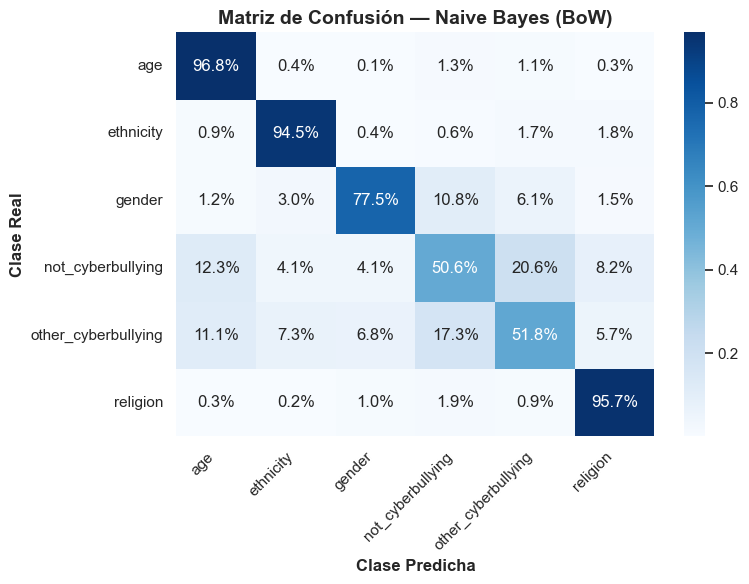

[Naive Bayes (BoW)] Accuracy: 0.7941 | F1 Macro: 0.7720 | Tiempo: 0.07s


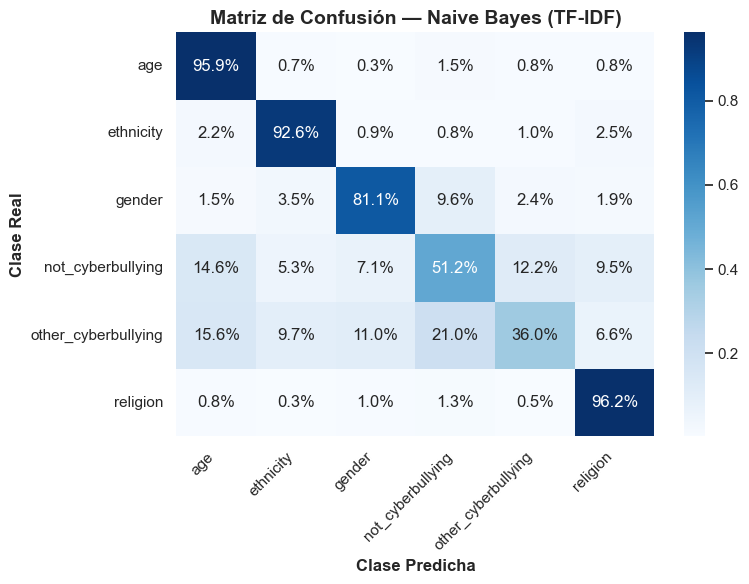

[Naive Bayes (TF-IDF)] Accuracy: 0.7772 | F1 Macro: 0.7450 | Tiempo: 0.07s
>> Como se observa, usaremos TF-IDF para los modelos avanzados dado su enfoque en la relevancia de términos.


In [10]:
# Naive Bayes con Bag of Words
t0 = time.time()
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
t_bow = time.time() - t0
evaluar_modelo("Naive Bayes (BoW)", y_test, nb_bow.predict(X_test_bow), t_bow)

# Naive Bayes con TF-IDF
t0 = time.time()
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
t_tfidf = time.time() - t0
evaluar_modelo("Naive Bayes (TF-IDF)", y_test, nb_tfidf.predict(X_test_tfidf), t_tfidf)

print(">> Como se observa, usaremos TF-IDF para los modelos avanzados dado su enfoque en la relevancia de términos.")

### 5.2 Modelos Avanzados (LinearSVC y MLP Neural Network)

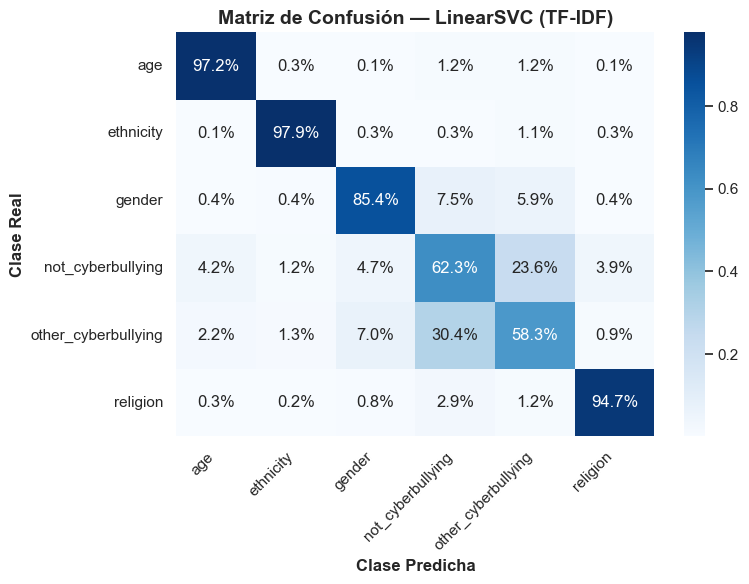

[LinearSVC (TF-IDF)] Accuracy: 0.8406 | F1 Macro: 0.8258 | Tiempo: 1.42s


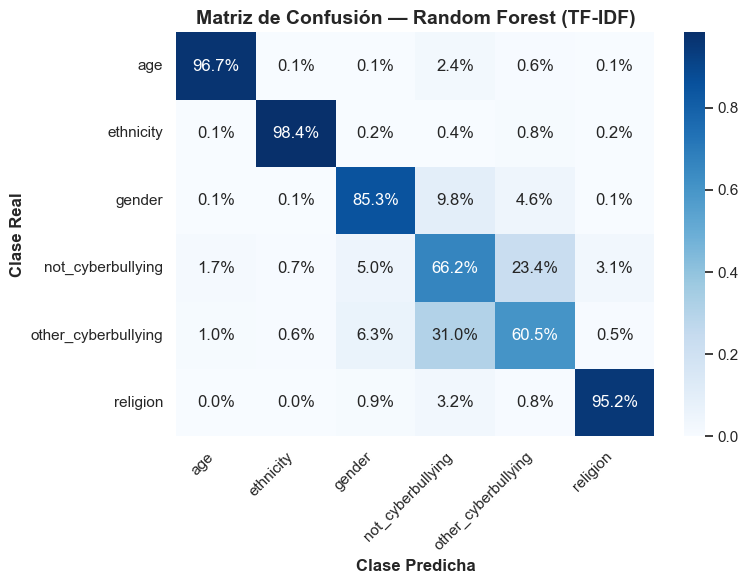

[Random Forest (TF-IDF)] Accuracy: 0.8506 | F1 Macro: 0.8383 | Tiempo: 13.64s


In [11]:
# --- Arquitectura 2: Modelo Lineal (LinearSVC) ---
t0 = time.time()
svm_model = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)
t_svm = time.time() - t0
evaluar_modelo("LinearSVC (TF-IDF)", y_test, svm_model.predict(X_test_tfidf), t_svm)

# --- Arquitectura 3: Ensamble (Random Forest) ---
t0 = time.time()
# Usamos n_jobs=-1 para usar todos los núcleos del procesador y que sea más rápido
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
t_rf = time.time() - t0
evaluar_modelo("Random Forest (TF-IDF)", y_test, rf_model.predict(X_test_tfidf), t_rf)

### 6. Comparación Final y Selección del Modelo

,Modelo,Accuracy,F1 Macro,Tiempo (s)
3,Random Forest (TF-IDF),0.850623,0.838342,13.640966
2,LinearSVC (TF-IDF),0.840606,0.825808,1.421492
0,Naive Bayes (BoW),0.794078,0.772037,0.072898
1,Naive Bayes (TF-IDF),0.777159,0.745028,0.068454


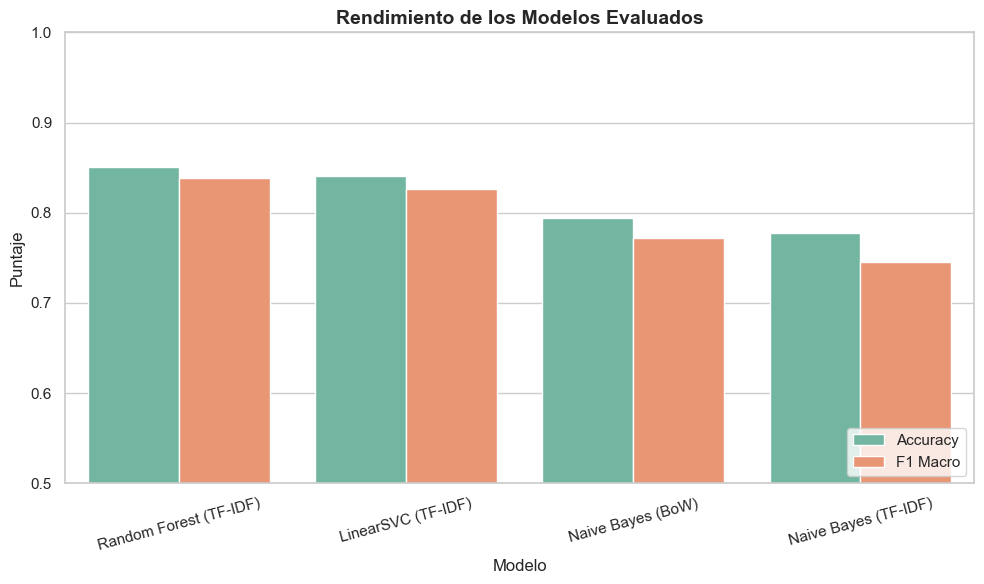

In [12]:
df_res = pd.DataFrame(resultados_modelos).sort_values(by="F1 Macro", ascending=False)
display(df_res)

# Gráfica comparativa
df_melted = df_res.melt(id_vars="Modelo", value_vars=["Accuracy", "F1 Macro"], var_name="Métrica", value_name="Puntaje")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="Modelo", y="Puntaje", hue="Métrica", palette="Set2")
plt.title("Rendimiento de los Modelos Evaluados", fontsize=14, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

mejor_modelo = svm_model

### 7. Pruebas de Usuario (Sistema en Vivo)

In [13]:
def detector_ciberacoso(tweet):
    texto_procesado = procesar_texto(tweet)
    vector = tfidf_vectorizer.transform([texto_procesado])
    prediccion = mejor_modelo.predict(vector)[0]
    
    print(f"Tweet Original : '{tweet}'")
    print(f"Predicción     : [ {prediccion.upper()} ]\n")

# Pruebas simuladas
detector_ciberacoso("You are too old to understand this, grandpa!")
detector_ciberacoso("Women should just stay in the kitchen.")
detector_ciberacoso("Have a wonderful day everyone, stay positive!")

Tweet Original : 'You are too old to understand this, grandpa!'
Predicción     : [ NOT_CYBERBULLYING ]

Tweet Original : 'Women should just stay in the kitchen.'
Predicción     : [ NOT_CYBERBULLYING ]

Tweet Original : 'Have a wonderful day everyone, stay positive!'
Predicción     : [ OTHER_CYBERBULLYING ]



### 8. Análisis de Overfitting (Entrenamiento vs. Prueba)
Para asegurar que nuestros modelos generalizan correctamente y no están memorizando los datos, comparamos el rendimiento (Accuracy) en el conjunto de entrenamiento contra el conjunto de prueba.

In [15]:
print("=== ANÁLISIS DE OVERFITTING (Accuracy Train vs Test) ===")

# Evaluación Naive Bayes (Probabilístico)
train_acc_nb = accuracy_score(y_train, nb_tfidf.predict(X_train_tfidf))
test_acc_nb = accuracy_score(y_test, nb_tfidf.predict(X_test_tfidf))
print(f"Naive Bayes     -> Train: {train_acc_nb:.4f} | Test: {test_acc_nb:.4f} | Dif: {train_acc_nb - test_acc_nb:.4f}")

# Evaluación LinearSVC (Lineal)
train_acc_svm = accuracy_score(y_train, svm_model.predict(X_train_tfidf))
test_acc_svm = accuracy_score(y_test, svm_model.predict(X_test_tfidf))
print(f"LinearSVC       -> Train: {train_acc_svm:.4f} | Test: {test_acc_svm:.4f} | Dif: {train_acc_svm - test_acc_svm:.4f}")

# Evaluación Random Forest (Ensamble)
train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train_tfidf))
test_acc_rf = accuracy_score(y_test, rf_model.predict(X_test_tfidf))
print(f"Random Forest   -> Train: {train_acc_rf:.4f} | Test: {test_acc_rf:.4f} | Dif: {train_acc_rf - test_acc_rf:.4f}")

=== ANÁLISIS DE OVERFITTING (Accuracy Train vs Test) ===
Naive Bayes     -> Train: 0.8211 | Test: 0.7772 | Dif: 0.0439
LinearSVC       -> Train: 0.9238 | Test: 0.8406 | Dif: 0.0831
Random Forest   -> Train: 0.9971 | Test: 0.8506 | Dif: 0.1465


### 9. Análisis de Errores (Ejemplos Mal Clasificados)
A continuación, exploramos en qué casos el modelo LinearSVC (nuestro mejor modelo) se está equivocando, para entender las confusiones más comunes.

In [16]:
y_pred_svm = svm_model.predict(X_test_tfidf)

# Crear Dataframe de comparación
df_analisis = pd.DataFrame({
    'Texto Original (Limpio)': X_test.values,
    'Clase Real': y_test.values,
    'Predicción': y_pred_svm
})

# Separar aciertos y errores
df_errores = df_analisis[df_analisis['Clase Real'] != df_analisis['Predicción']]
df_aciertos = df_analisis[df_analisis['Clase Real'] == df_analisis['Predicción']]

print(f"Total de errores: {len(df_errores)} | Total de aciertos: {len(df_aciertos)}\n")

print("=== Pares de clases más comunes de confusión ===")
confusiones = df_errores.groupby(['Clase Real', 'Predicción']).size().reset_index(name='Cantidad')
confusiones = confusiones.sort_values('Cantidad', ascending=False).head(5)
display(confusiones)

print("\n=== Ejemplos de tweets MAL clasificados ===")
display(df_errores.head(3))

print("\n=== Ejemplos de tweets BIEN clasificados ===")
display(df_aciertos.head(3))

Total de errores: 1432 | Total de aciertos: 7552

=== Pares de clases más comunes de confusión ===


,Clase Real,Predicción,Cantidad
18,not_cyberbullying,other_cyberbullying,353
23,other_cyberbullying,not_cyberbullying,347
12,gender,not_cyberbullying,117
13,gender,other_cyberbullying,92
22,other_cyberbullying,gender,80



=== Ejemplos de tweets MAL clasificados ===


,Texto Original (Limpio),Clase Real,Predicción
0,ahaha funniest thing ever price right woman su...,not_cyberbullying,other_cyberbullying
2,wired wrong,other_cyberbullying,not_cyberbullying
4,didnt say anything tho kiss faggot,gender,ethnicity



=== Ejemplos de tweets BIEN clasificados ===


,Texto Original (Limpio),Clase Real,Predicción
1,hey girl tried sell pyramid scheme shit girl b...,age,age
3,mohammad agia sofia muslim monument idiot,religion,religion
5,imagine kind bully must school towards others,age,age
